# BERT: Bidirectional Encoder Representations from Transformers

## 1. Introduction

BERT revolutionized NLP by introducing **bidirectional pre-training** - the model sees both left and right context simultaneously. This is different from traditional left-to-right language models (like GPT) that only see previous tokens.

### What we'll learn:
- How BERT's **bidirectional architecture** differs from unidirectional models
- The **Masked Language Modeling (MLM)** pre-training objective
- How BERT uses **WordPiece tokenization** and special tokens
- Building a simplified BERT encoder from scratch
- Applying BERT to a text classification task
- Why bidirectionality matters for understanding tasks

### Key Innovation:
BERT uses a **masked language model** - randomly masking input tokens and predicting them using both left and right context. This forces the model to learn deep bidirectional representations, making it excellent for understanding tasks like classification, question answering, and named entity recognition.

## 2. Setup

First, let's import the libraries we'll need and configure our environment.

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
from tqdm.auto import tqdm

from aiml_notebooks import get_device, set_seed

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set random seed for reproducibility.

In [53]:
set_seed(42)

Configure device (prefer CPU for transformer operations to avoid MPS issues).

In [54]:
device = get_device(prefer_cpu=True)

Using CPU
Note: MPS is available but not used due to compatibility issues
To use MPS with CPU fallback, run: PYTORCH_ENABLE_MPS_FALLBACK=1 jupyter lab


## 3. BERT vs Unidirectional Models

### Understanding Bidirectionality

The key difference between BERT and GPT-style models is in how they process context:

**Unidirectional (GPT)**: Predicts next token using only previous tokens
- Sentence: "The cat sat on the mat"
- Predicting "sat": Can only see "The cat" (left context)

**Bidirectional (BERT)**: Predicts masked token using both left and right context
- Sentence: "The cat [MASK] on the mat"
- Predicting [MASK]: Can see "The cat" (left) AND "on the mat" (right)

This bidirectional context is crucial for understanding tasks where full sentence meaning matters.

Let's visualize the attention patterns for both approaches.

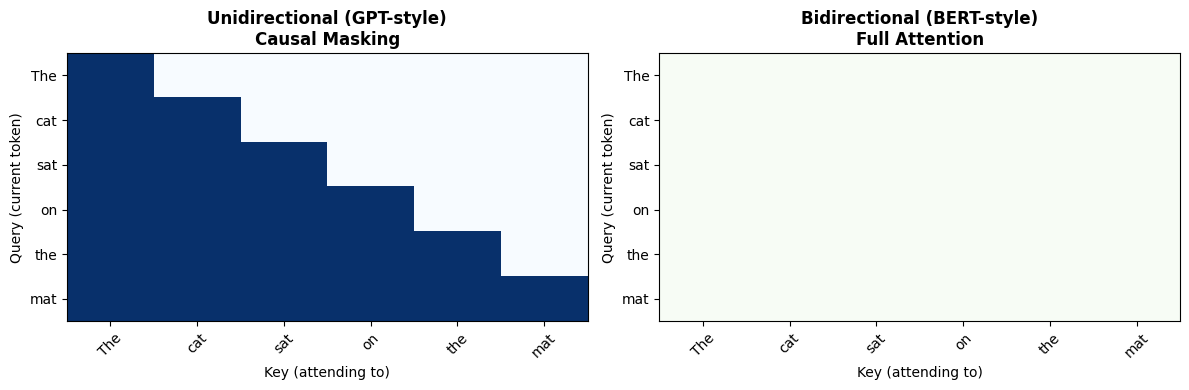

White = Can attend, Dark = Masked

Unidirectional: Each token can only see itself and previous tokens
Bidirectional: Each token can see ALL tokens (full context)


In [55]:
def visualize_attention_patterns():
    """Compare unidirectional vs bidirectional attention patterns."""
    seq_len = 6
    tokens = ["The", "cat", "sat", "on", "the", "mat"]
    
    # Create attention masks
    # Unidirectional: causal mask (can only attend to previous tokens)
    causal_mask = torch.tril(torch.ones(seq_len, seq_len))
    
    # Bidirectional: full attention (can attend to all tokens)
    bidirectional_mask = torch.ones(seq_len, seq_len)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot causal (unidirectional)
    im1 = axes[0].imshow(causal_mask, cmap='Blues', aspect='auto')
    axes[0].set_title('Unidirectional (GPT-style)\nCausal Masking', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Key (attending to)')
    axes[0].set_ylabel('Query (current token)')
    axes[0].set_xticks(range(seq_len))
    axes[0].set_yticks(range(seq_len))
    axes[0].set_xticklabels(tokens, rotation=45)
    axes[0].set_yticklabels(tokens)
    
    # Plot bidirectional
    im2 = axes[1].imshow(bidirectional_mask, cmap='Greens', aspect='auto')
    axes[1].set_title('Bidirectional (BERT-style)\nFull Attention', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Key (attending to)')
    axes[1].set_ylabel('Query (current token)')
    axes[1].set_xticks(range(seq_len))
    axes[1].set_yticks(range(seq_len))
    axes[1].set_xticklabels(tokens, rotation=45)
    axes[1].set_yticklabels(tokens)
    
    plt.tight_layout()
    plt.show()
    
    print("White = Can attend, Dark = Masked")
    print("\nUnidirectional: Each token can only see itself and previous tokens")
    print("Bidirectional: Each token can see ALL tokens (full context)")

visualize_attention_patterns()

**Key Insight**: Bidirectional attention allows each token to incorporate information from the entire sequence. This is why BERT excels at tasks requiring full sentence understanding (classification, NER, question answering) but cannot be used for autoregressive generation without modifications.

## 4. Masked Language Modeling (MLM)

### The Pre-training Objective

BERT's main pre-training task is **Masked Language Modeling (MLM)**:
1. Randomly mask 15% of input tokens
2. Predict the masked tokens using bidirectional context
3. Loss is computed only on masked positions

**Masking Strategy** (for each selected token):
- 80% of the time: Replace with [MASK] token
- 10% of the time: Replace with random token
- 10% of the time: Keep unchanged

This prevents the model from only learning representations for [MASK] tokens.

Let's implement the masking strategy.

In [56]:
class MaskedLMData:
    """Create masked language modeling training examples."""
    
    def __init__(self, mask_token_id, vocab_size, mask_prob=0.15):
        self.mask_token_id = mask_token_id
        self.vocab_size = vocab_size
        self.mask_prob = mask_prob
    
    def mask_tokens(self, tokens):
        """
        Apply MLM masking strategy.
        
        Args:
            tokens: Tensor of shape (batch_size, seq_len)
        
        Returns:
            masked_tokens: Tokens with masking applied
            labels: Original tokens (with -100 for unmasked positions)
        """
        labels = tokens.clone()
        
        # Create probability matrix for masking
        probability_matrix = torch.full(tokens.shape, self.mask_prob)
        
        # Don't mask padding tokens (assuming 0 is padding)
        padding_mask = tokens == 0
        probability_matrix.masked_fill_(padding_mask, value=0.0)
        
        # Select positions to mask
        masked_indices = torch.bernoulli(probability_matrix).bool()
        
        # Set unmasked positions to -100 (ignored in loss)
        labels[~masked_indices] = -100
        
        # 80% of the time: replace with [MASK]
        indices_replaced = torch.bernoulli(torch.full(tokens.shape, 0.8)).bool() & masked_indices
        tokens = tokens.clone()
        tokens[indices_replaced] = self.mask_token_id
        
        # 10% of the time: replace with random token
        indices_random = torch.bernoulli(torch.full(tokens.shape, 0.5)).bool() & masked_indices & ~indices_replaced
        random_tokens = torch.randint(self.vocab_size, tokens.shape, dtype=torch.long)
        tokens[indices_random] = random_tokens[indices_random]
        
        # 10% of the time: keep original (no change needed)
        
        return tokens, labels

Visualize the masking process on a sample sentence.

In [57]:
# Create dummy tokenizer for demonstration
def demo_masking():
    vocab = ['<PAD>', '<MASK>', 'the', 'cat', 'sat', 'on', 'a', 'mat']
    vocab_size = len(vocab)
    mask_token_id = 1
    
    # Create sample sentence: "the cat sat on a mat"
    tokens = torch.tensor([[2, 3, 4, 5, 6, 7]])  # Shape: (1, 6)
    
    masker = MaskedLMData(mask_token_id, vocab_size, mask_prob=0.5)  # Higher prob for demo
    masked_tokens, labels = masker.mask_tokens(tokens)
    
    print("Original sentence:")
    print(' '.join([vocab[i] for i in tokens[0].tolist()]))
    print(f"Token IDs: {tokens[0].tolist()}")
    
    print("\nMasked sentence:")
    print(' '.join([vocab[i] if i < len(vocab) else '<UNK>' for i in masked_tokens[0].tolist()]))
    print(f"Token IDs: {masked_tokens[0].tolist()}")
    
    print("\nLabels (targets for loss):")
    label_strs = [vocab[i] if i >= 0 else '<IGNORE>' for i in labels[0].tolist()]
    print(' '.join(label_strs))
    print(f"Token IDs: {labels[0].tolist()}")
    
    print("\nNote: Only masked positions (not -100) contribute to the loss.")

demo_masking()

Original sentence:
the cat sat on a mat
Token IDs: [2, 3, 4, 5, 6, 7]

Masked sentence:
the cat sat on a mat
Token IDs: [2, 3, 4, 5, 6, 7]

Labels (targets for loss):
<IGNORE> <IGNORE> sat <IGNORE> a <IGNORE>
Token IDs: [-100, -100, 4, -100, 6, -100]

Note: Only masked positions (not -100) contribute to the loss.


**Key Insight**: MLM forces the model to learn rich contextual representations. Unlike next-token prediction (which is easier because of left-to-right context), predicting masked tokens requires understanding the entire sentence structure.

## 5. BERT Architecture Components

### 5.1 WordPiece Tokenization and Special Tokens

BERT uses **WordPiece tokenization** which splits words into subword units:
- Common words: single token ("cat" → "cat")
- Rare words: multiple subwords ("playing" → "play" + "##ing")

**Special Tokens**:
- `[CLS]`: Classification token (added at start, used for sentence-level tasks)
- `[SEP]`: Separator token (separates sentences in sentence-pair tasks)
- `[MASK]`: Mask token (used during pre-training)
- `[PAD]`: Padding token (for batching variable-length sequences)

For simplicity, we'll use character-level tokenization but apply the same special token concepts.

Create a simple tokenizer with BERT-style special tokens.

In [58]:
class SimpleBERTTokenizer:
    """Simple character-level tokenizer with BERT special tokens."""
    
    def __init__(self, texts):
        # Special tokens
        self.PAD = '[PAD]'
        self.CLS = '[CLS]'
        self.SEP = '[SEP]'
        self.MASK = '[MASK]'
        
        # Build vocabulary
        chars = set()
        for text in texts:
            chars.update(text.lower())
        
        # Create char to index mapping (special tokens first)
        special_tokens = [self.PAD, self.CLS, self.SEP, self.MASK]
        vocab = special_tokens + sorted(list(chars))
        
        self.char2idx = {char: idx for idx, char in enumerate(vocab)}
        self.idx2char = {idx: char for char, idx in self.char2idx.items()}
        self.vocab_size = len(vocab)
        
        # Special token IDs
        self.pad_token_id = self.char2idx[self.PAD]
        self.cls_token_id = self.char2idx[self.CLS]
        self.sep_token_id = self.char2idx[self.SEP]
        self.mask_token_id = self.char2idx[self.MASK]
    
    def encode(self, text, add_special_tokens=True, max_length=None):
        """Encode text to token IDs."""
        text = text.lower()
        indices = [self.char2idx.get(char, self.pad_token_id) for char in text]
        
        if add_special_tokens:
            # Add [CLS] at start and [SEP] at end
            indices = [self.cls_token_id] + indices + [self.sep_token_id]
        
        if max_length is not None:
            if len(indices) > max_length:
                indices = indices[:max_length]
            else:
                indices = indices + [self.pad_token_id] * (max_length - len(indices))
        
        return indices
    
    def decode(self, indices):
        """Decode token IDs to text."""
        chars = []
        for idx in indices:
            char = self.idx2char[idx]
            # Stop at [SEP] token
            if char == self.SEP:
                break
            # Skip special tokens but preserve regular characters and spaces
            if char not in [self.PAD, self.CLS, self.MASK]:
                chars.append(char)
        return ''.join(chars)

Test the tokenizer on sample sentences.

In [ ]:
# Create tokenizer
sample_texts = ['the cat sat on the mat', 'dogs are great', 'machine learning is fun', 'hello world']
tokenizer = SimpleBERTTokenizer(sample_texts)

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Special token IDs:")
print(f"  [PAD]: {tokenizer.pad_token_id}")
print(f"  [CLS]: {tokenizer.cls_token_id}")
print(f"  [SEP]: {tokenizer.sep_token_id}")
print(f"  [MASK]: {tokenizer.mask_token_id}")

# Test encoding/decoding
text = "hello world"
encoded = tokenizer.encode(text, max_length=20)
decoded = tokenizer.decode(encoded)

print(f"\nOriginal: {text}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Vocabulary size: 21
Special token IDs:
  [PAD]: 0
  [CLS]: 1
  [SEP]: 2
  [MASK]: 3

Original: hello world
Encoded: [1, 11, 8, 13, 13, 16, 4, 0, 16, 17, 13, 7, 2, 0, 0, 0, 0, 0, 0, 0]
Decoded: hello orld


### 5.2 Input Embeddings

BERT combines three types of embeddings for each token:

1. **Token Embeddings**: Learned representation for each vocabulary item
2. **Position Embeddings**: Learned representation for each position (unlike sinusoidal in vanilla Transformer)
3. **Segment Embeddings**: Distinguishes between sentence A and B (for sentence-pair tasks)

Final embedding: `Token Embedding + Position Embedding + Segment Embedding`

Implement BERT's embedding layer.

In [60]:
class BERTEmbeddings(nn.Module):
    """BERT-style embeddings: token + position + segment."""
    
    def __init__(self, vocab_size, hidden_size, max_position_embeddings=512, dropout=0.1):
        super().__init__()
        
        # Token embeddings
        self.token_embeddings = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        
        # Position embeddings (learned, not sinusoidal)
        self.position_embeddings = nn.Embedding(max_position_embeddings, hidden_size)
        
        # Segment embeddings (for sentence pairs: sentence A vs B)
        self.segment_embeddings = nn.Embedding(2, hidden_size)
        
        # LayerNorm and dropout
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, input_ids, segment_ids=None):
        """
        Args:
            input_ids: (batch_size, seq_len)
            segment_ids: (batch_size, seq_len), optional
        
        Returns:
            embeddings: (batch_size, seq_len, hidden_size)
        """
        batch_size, seq_len = input_ids.shape
        
        # Token embeddings
        token_embeds = self.token_embeddings(input_ids)  # (batch, seq_len, hidden)
        
        # Position embeddings
        position_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)
        position_embeds = self.position_embeddings(position_ids)  # (batch, seq_len, hidden)
        
        # Segment embeddings (default to all 0s if not provided)
        if segment_ids is None:
            segment_ids = torch.zeros_like(input_ids)
        segment_embeds = self.segment_embeddings(segment_ids)  # (batch, seq_len, hidden)
        
        # Combine all embeddings
        embeddings = token_embeds + position_embeds + segment_embeds
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        
        return embeddings

Test the embedding layer and visualize the three embedding types.

In [61]:
# Create embedding layer
embed_layer = BERTEmbeddings(vocab_size=tokenizer.vocab_size, hidden_size=128)

# Create sample input
text1 = "hello world"
text2 = "bert is cool"

# Encode with max length
ids1 = tokenizer.encode(text1, max_length=15)
ids2 = tokenizer.encode(text2, max_length=15)

# Create batch
input_ids = torch.tensor([ids1, ids2])  # (2, 15)

# Create segment IDs (first sentence vs second sentence)
# For single sentence: all 0s
segment_ids = torch.zeros_like(input_ids)

# Get embeddings
embeddings = embed_layer(input_ids, segment_ids)

print(f"Input shape: {input_ids.shape}")
print(f"Embedding shape: {embeddings.shape}")
print(f"\nFirst token embeddings (first 10 dims): {embeddings[0, 0, :10]}")

Input shape: torch.Size([2, 15])
Embedding shape: torch.Size([2, 15, 128])

First token embeddings (first 10 dims): tensor([ 0.1468,  1.6700,  0.0000,  0.4468, -2.1815, -1.9548, -0.5773,  0.5756,
         0.0000, -1.8164], grad_fn=<SliceBackward0>)


**Key Insight**: Unlike the original Transformer, BERT uses **learned positional embeddings** instead of sinusoidal ones. This allows the model to learn position-specific patterns but limits maximum sequence length (typically 512 tokens).

### 5.3 Multi-Head Self-Attention

BERT uses standard multi-head self-attention (same as the Transformer). The key difference is that there's **no causal masking** - each token can attend to all other tokens in both directions.

Implement multi-head attention for BERT.

In [62]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention mechanism."""
    
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"
        
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        
        # Q, K, V projections
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)
        
        # Output projection
        self.out = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, attention_mask=None):
        """
        Args:
            x: (batch_size, seq_len, hidden_size)
            attention_mask: (batch_size, seq_len) - 1 for valid tokens, 0 for padding
        
        Returns:
            output: (batch_size, seq_len, hidden_size)
            attention_weights: (batch_size, num_heads, seq_len, seq_len)
        """
        batch_size, seq_len, hidden_size = x.shape
        
        # Linear projections and reshape for multi-head
        # (batch, seq_len, hidden) -> (batch, seq_len, num_heads, head_dim) -> (batch, num_heads, seq_len, head_dim)
        Q = self.query(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Scaled dot-product attention
        # (batch, num_heads, seq_len, head_dim) @ (batch, num_heads, head_dim, seq_len)
        # -> (batch, num_heads, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim)
        
        # Apply attention mask (mask out padding tokens)
        if attention_mask is not None:
            # Expand mask for broadcasting: (batch, 1, 1, seq_len)
            attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)
            # Set masked positions to large negative value
            scores = scores.masked_fill(attention_mask == 0, -1e9)
        
        # Softmax and dropout
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # Apply attention to values
        # (batch, num_heads, seq_len, seq_len) @ (batch, num_heads, seq_len, head_dim)
        # -> (batch, num_heads, seq_len, head_dim)
        context = torch.matmul(attention_weights, V)
        
        # Reshape back: (batch, num_heads, seq_len, head_dim) -> (batch, seq_len, hidden)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, hidden_size)
        
        # Output projection
        output = self.out(context)
        
        return output, attention_weights

Test the attention mechanism with a sample input.

In [63]:
# Create attention layer
attention = MultiHeadAttention(hidden_size=128, num_heads=8)

# Use embeddings from previous cell
output, attn_weights = attention(embeddings)

print(f"Input shape: {embeddings.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"  (batch_size, num_heads, seq_len, seq_len)")

Input shape: torch.Size([2, 15, 128])
Output shape: torch.Size([2, 15, 128])
Attention weights shape: torch.Size([2, 8, 15, 15])
  (batch_size, num_heads, seq_len, seq_len)


Visualize attention patterns for the first head.

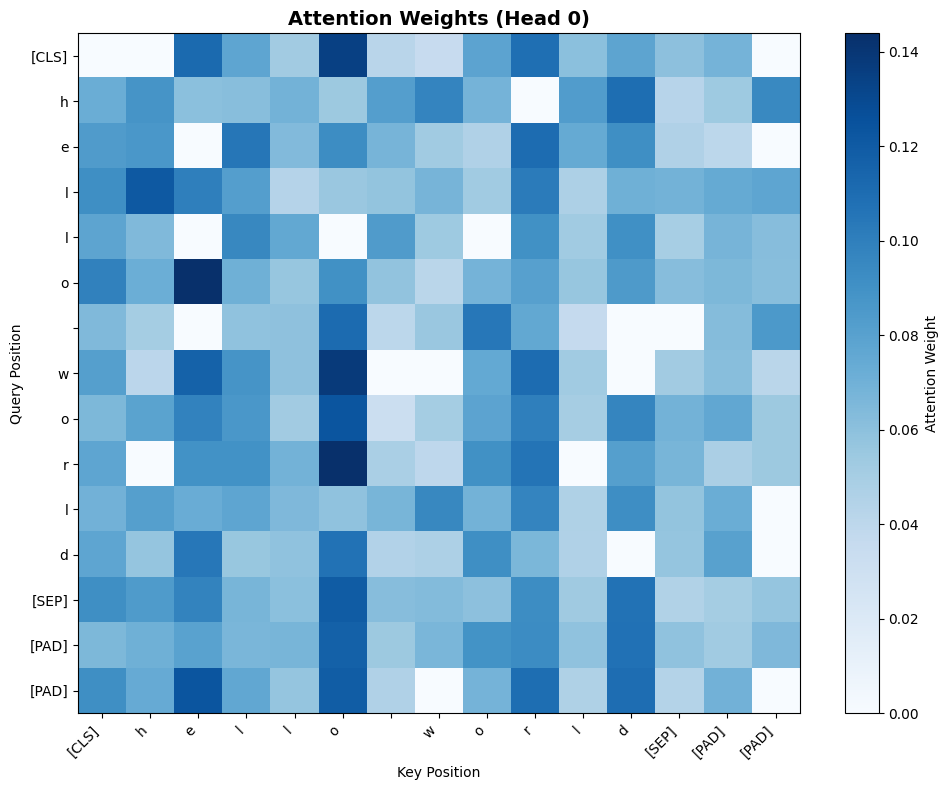

In [64]:
def visualize_attention(attn_weights, tokens, head_idx=0, sample_idx=0):
    """Visualize attention weights for a specific head."""
    # Get attention for specific sample and head
    attn = attn_weights[sample_idx, head_idx].detach().numpy()
    
    plt.figure(figsize=(10, 8))
    plt.imshow(attn, cmap='Blues', aspect='auto')
    plt.colorbar(label='Attention Weight')
    plt.title(f'Attention Weights (Head {head_idx})', fontsize=14, fontweight='bold')
    plt.xlabel('Key Position')
    plt.ylabel('Query Position')
    
    # Add token labels if provided
    if tokens:
        plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
        plt.yticks(range(len(tokens)), tokens)
    
    plt.tight_layout()
    plt.show()

# Get tokens for visualization
sample_tokens = ['[CLS]'] + list('hello world') + ['[SEP]', '[PAD]', '[PAD]']
visualize_attention(attn_weights, sample_tokens[:15], head_idx=0)

**Key Insight**: Each token can attend to ALL positions (full bidirectional attention). Notice how attention weights form a full matrix, unlike the triangular pattern in GPT-style models.

### 5.4 Feed-Forward Network

After attention, BERT applies a position-wise feed-forward network (same as Transformer):
- Two linear layers with GELU activation in between
- Expands to intermediate size (typically 4x hidden size) then projects back

BERT uses **GELU** (Gaussian Error Linear Unit) instead of ReLU, which provides smoother gradients.

Implement the feed-forward network.

In [65]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network with GELU activation."""
    
    def __init__(self, hidden_size, intermediate_size, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(hidden_size, intermediate_size)
        self.fc2 = nn.Linear(intermediate_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len, hidden_size)
        
        Returns:
            output: (batch_size, seq_len, hidden_size)
        """
        x = self.fc1(x)
        x = F.gelu(x)  # GELU activation (smoother than ReLU)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

Compare GELU and ReLU activations to see the difference.

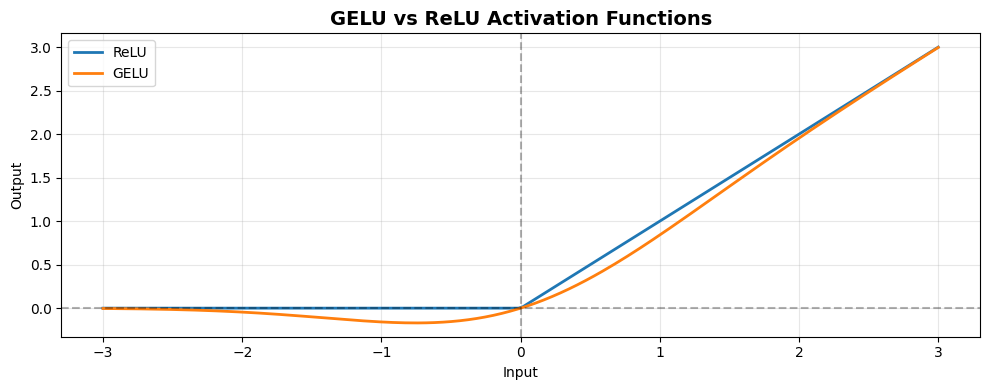

GELU advantages:
- Smooth, differentiable everywhere (unlike ReLU which has sharp corner at 0)
- Allows small negative values (not zero like ReLU)
- Better gradient flow during training


In [87]:
def compare_activations():
    """Visualize GELU vs ReLU activation functions."""
    x = torch.linspace(-3, 3, 200)
    relu = F.relu(x)
    gelu = F.gelu(x)
    
    plt.figure(figsize=(10, 4))
    plt.plot(x.numpy(), relu.numpy(), label='ReLU', linewidth=2)
    plt.plot(x.numpy(), gelu.numpy(), label='GELU', linewidth=2)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.title('GELU vs ReLU Activation Functions', fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("GELU advantages:")
    print("- Smooth, differentiable everywhere (unlike ReLU which has sharp corner at 0)")
    print("- Allows small negative values (not zero like ReLU)")
    print("- Better gradient flow during training")

compare_activations()

### 5.5 BERT Encoder Layer

A complete BERT encoder layer combines:
1. Multi-head self-attention
2. Add & Norm (residual connection + layer normalization)
3. Feed-forward network
4. Add & Norm (residual connection + layer normalization)

This is identical to the Transformer encoder layer structure.

Implement a complete BERT encoder layer.

In [67]:
class BERTEncoderLayer(nn.Module):
    """Single BERT encoder layer with self-attention and feed-forward."""
    
    def __init__(self, hidden_size, num_heads, intermediate_size, dropout=0.1):
        super().__init__()
        
        # Multi-head attention
        self.attention = MultiHeadAttention(hidden_size, num_heads, dropout)
        
        # Feed-forward network
        self.feed_forward = FeedForward(hidden_size, intermediate_size, dropout)
        
        # Layer normalization
        self.ln1 = nn.LayerNorm(hidden_size)
        self.ln2 = nn.LayerNorm(hidden_size)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, attention_mask=None):
        """
        Args:
            x: (batch_size, seq_len, hidden_size)
            attention_mask: (batch_size, seq_len)
        
        Returns:
            output: (batch_size, seq_len, hidden_size)
        """
        # Self-attention with residual connection
        attn_output, _ = self.attention(x, attention_mask)
        x = self.ln1(x + self.dropout(attn_output))
        
        # Feed-forward with residual connection
        ff_output = self.feed_forward(x)
        x = self.ln2(x + self.dropout(ff_output))
        
        return x

Test a single encoder layer.

In [68]:
# Create encoder layer
encoder_layer = BERTEncoderLayer(
    hidden_size=128,
    num_heads=8,
    intermediate_size=512,
    dropout=0.1
)

# Test with embeddings
output = encoder_layer(embeddings)

print(f"Input shape: {embeddings.shape}")
print(f"Output shape: {output.shape}")
print(f"\nOutput statistics:")
print(f"  Mean: {output.mean().item():.4f}")
print(f"  Std: {output.std().item():.4f}")
print(f"\nLayer normalization keeps outputs well-scaled")

Input shape: torch.Size([2, 15, 128])
Output shape: torch.Size([2, 15, 128])

Output statistics:
  Mean: 0.0000
  Std: 1.0001

Layer normalization keeps outputs well-scaled


## 6. Complete BERT Model

Now let's assemble the complete BERT model by stacking multiple encoder layers.

Implement the full BERT architecture.

In [69]:
class SimpleBERT(nn.Module):
    """Simplified BERT model for educational purposes."""
    
    def __init__(
        self,
        vocab_size,
        hidden_size=256,
        num_layers=6,
        num_heads=8,
        intermediate_size=1024,
        max_position_embeddings=512,
        dropout=0.1
    ):
        super().__init__()
        
        self.embeddings = BERTEmbeddings(
            vocab_size=vocab_size,
            hidden_size=hidden_size,
            max_position_embeddings=max_position_embeddings,
            dropout=dropout
        )
        
        # Stack of encoder layers
        self.encoder_layers = nn.ModuleList([
            BERTEncoderLayer(hidden_size, num_heads, intermediate_size, dropout)
            for _ in range(num_layers)
        ])
        
        self.hidden_size = hidden_size
    
    def forward(self, input_ids, attention_mask=None, segment_ids=None):
        """
        Args:
            input_ids: (batch_size, seq_len)
            attention_mask: (batch_size, seq_len), optional
            segment_ids: (batch_size, seq_len), optional
        
        Returns:
            sequence_output: (batch_size, seq_len, hidden_size)
            pooled_output: (batch_size, hidden_size) - [CLS] token representation
        """
        # Create attention mask if not provided (mask out padding)
        if attention_mask is None:
            attention_mask = (input_ids != 0).long()
        
        # Get embeddings
        x = self.embeddings(input_ids, segment_ids)
        
        # Pass through encoder layers
        for encoder_layer in self.encoder_layers:
            x = encoder_layer(x, attention_mask)
        
        # Sequence output (all token representations)
        sequence_output = x
        
        # Pooled output ([CLS] token for classification)
        pooled_output = sequence_output[:, 0, :]  # First token ([CLS])
        
        return sequence_output, pooled_output

Create a BERT model and examine its architecture.

In [70]:
# Create BERT model
bert = SimpleBERT(
    vocab_size=tokenizer.vocab_size,
    hidden_size=256,
    num_layers=4,
    num_heads=8,
    intermediate_size=1024,
    dropout=0.1
)

# Count parameters
total_params = sum(p.numel() for p in bert.parameters())
trainable_params = sum(p.numel() for p in bert.parameters() if p.requires_grad)

print("BERT Model Architecture:")
print(f"  Vocabulary size: {tokenizer.vocab_size}")
print(f"  Hidden size: {bert.hidden_size}")
print(f"  Number of layers: {len(bert.encoder_layers)}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
sequence_output, pooled_output = bert(input_ids)

print(f"\nForward pass:")
print(f"  Input shape: {input_ids.shape}")
print(f"  Sequence output shape: {sequence_output.shape}")
print(f"  Pooled output shape: {pooled_output.shape}")

BERT Model Architecture:
  Vocabulary size: 21
  Hidden size: 256
  Number of layers: 4
  Total parameters: 3,296,512
  Trainable parameters: 3,296,512

Forward pass:
  Input shape: torch.Size([2, 15])
  Sequence output shape: torch.Size([2, 15, 256])
  Pooled output shape: torch.Size([2, 256])


**Key Insight**: The pooled output (CLS token representation) captures the entire sentence meaning and is used for sentence-level tasks like classification. The sequence output provides token-level representations for tasks like NER or question answering.

## 7. Text Classification with BERT

Let's apply BERT to a practical task: sentiment classification. We'll create a simple binary classifier on top of BERT's [CLS] token representation.

Create a BERT-based classifier.

In [71]:
class BERTClassifier(nn.Module):
    """BERT model with classification head."""
    
    def __init__(self, bert_model, num_classes, hidden_size):
        super().__init__()
        self.bert = bert_model
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, num_classes)
        )
    
    def forward(self, input_ids, attention_mask=None, segment_ids=None):
        """
        Args:
            input_ids: (batch_size, seq_len)
            attention_mask: (batch_size, seq_len), optional
            segment_ids: (batch_size, seq_len), optional
        
        Returns:
            logits: (batch_size, num_classes)
        """
        # Get BERT representations
        _, pooled_output = self.bert(input_ids, attention_mask, segment_ids)
        
        # Classify using [CLS] token representation
        logits = self.classifier(pooled_output)
        
        return logits

Create synthetic sentiment data for demonstration.

In [72]:
# Synthetic sentiment dataset
positive_texts = [
    "this is great",
    "i love it",
    "amazing work",
    "fantastic result",
    "wonderful experience",
    "really good",
    "excellent quality",
    "very happy"
]

negative_texts = [
    "this is bad",
    "i hate it",
    "terrible work",
    "awful result",
    "horrible experience",
    "really poor",
    "worst quality",
    "very sad"
]

# Combine and create labels
texts = positive_texts + negative_texts
labels = [1] * len(positive_texts) + [0] * len(negative_texts)  # 1 = positive, 0 = negative

print(f"Dataset size: {len(texts)} examples")
print(f"Positive: {sum(labels)}, Negative: {len(labels) - sum(labels)}")
print(f"\nSample:")
print(f"  Text: '{texts[0]}' -> Label: {labels[0]} (positive)")
print(f"  Text: '{texts[-1]}' -> Label: {labels[-1]} (negative)")

Dataset size: 16 examples
Positive: 8, Negative: 8

Sample:
  Text: 'this is great' -> Label: 1 (positive)
  Text: 'very sad' -> Label: 0 (negative)


Create tokenizer and encode the dataset.

In [73]:
# Create tokenizer from training data
classifier_tokenizer = SimpleBERTTokenizer(texts)

# Encode all texts
max_len = 30
encoded_texts = [classifier_tokenizer.encode(text, max_length=max_len) for text in texts]

# Convert to tensors
input_ids = torch.tensor(encoded_texts)
labels_tensor = torch.tensor(labels)

print(f"Encoded data shape: {input_ids.shape}")
print(f"Labels shape: {labels_tensor.shape}")
print(f"\nExample encoding:")
print(f"  Text: '{texts[0]}'")
print(f"  Encoded: {encoded_texts[0][:10]}...")

Encoded data shape: torch.Size([16, 30])
Labels shape: torch.Size([16])

Example encoding:
  Text: 'this is great'
  Encoded: [1, 23, 12, 13, 22, 4, 13, 22, 4, 11]...


Create BERT classifier and train it.

In [74]:
# Create fresh BERT model for classification
bert_base = SimpleBERT(
    vocab_size=classifier_tokenizer.vocab_size,
    hidden_size=128,
    num_layers=3,
    num_heads=4,
    intermediate_size=512,
    dropout=0.1
)

# Create classifier
classifier = BERTClassifier(
    bert_model=bert_base,
    num_classes=2,
    hidden_size=128
).to(device)

print("BERT Classifier created")
print(f"Total parameters: {sum(p.numel() for p in classifier.parameters()):,}")

BERT Classifier created
Total parameters: 681,474


Train the classifier on the sentiment data.

In [75]:
# Training setup
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Move data to device
input_ids = input_ids.to(device)
labels_tensor = labels_tensor.to(device)

# Training loop
classifier.train()
losses = []
accuracies = []

num_epochs = 100
for epoch in tqdm(range(num_epochs), desc="Training"):
    # Forward pass
    logits = classifier(input_ids)
    loss = criterion(logits, labels_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate accuracy
    predictions = torch.argmax(logits, dim=-1)
    accuracy = (predictions == labels_tensor).float().mean()
    
    losses.append(loss.item())
    accuracies.append(accuracy.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f} - Accuracy: {accuracy.item():.4f}")

print(f"\nFinal Training Accuracy: {accuracies[-1]:.2%}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20/100 - Loss: 0.1744 - Accuracy: 0.9375
Epoch 40/100 - Loss: 0.0022 - Accuracy: 1.0000
Epoch 60/100 - Loss: 0.3078 - Accuracy: 0.8125
Epoch 80/100 - Loss: 0.0039 - Accuracy: 1.0000
Epoch 100/100 - Loss: 0.0010 - Accuracy: 1.0000

Final Training Accuracy: 100.00%


Visualize training progress.

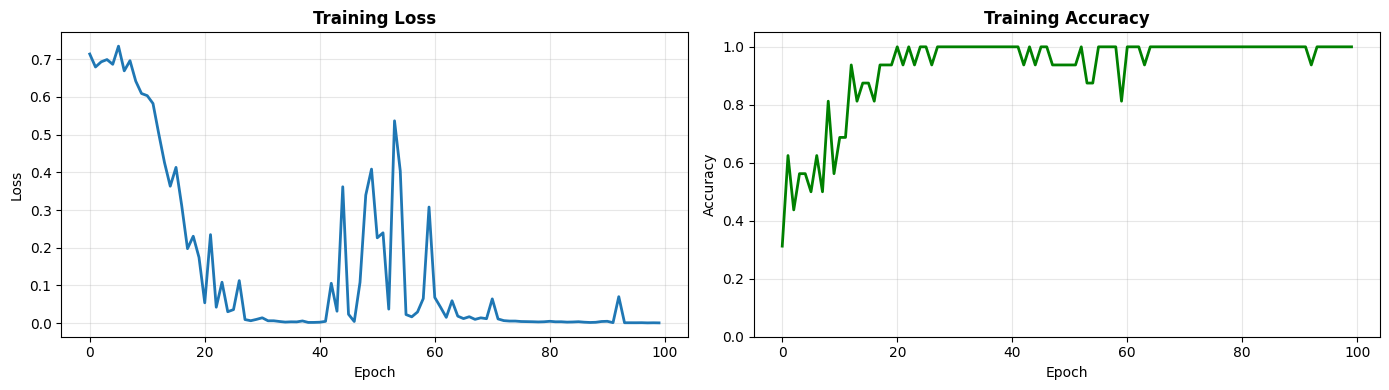

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(losses, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(accuracies, linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Test the trained classifier on new examples.

In [77]:
def predict_sentiment(text, model, tokenizer, device):
    """Predict sentiment for a text."""
    model.eval()
    with torch.no_grad():
        # Encode text
        encoded = tokenizer.encode(text, max_length=30)
        input_ids = torch.tensor([encoded]).to(device)
        
        # Predict
        logits = model(input_ids)
        probs = F.softmax(logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1)
        
        return prediction.item(), probs[0].cpu().numpy()

# Test on training examples
test_texts = [
    "this is great",
    "this is bad",
    "amazing",
    "terrible"
]

print("Sentiment Predictions:")
print("=" * 60)
for text in test_texts:
    pred, probs = predict_sentiment(text, classifier, classifier_tokenizer, device)
    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = probs[pred]
    print(f"Text: '{text:20s}' -> {sentiment:8s} (confidence: {confidence:.2%})")
    print(f"  Probabilities: Negative={probs[0]:.2%}, Positive={probs[1]:.2%}")

Sentiment Predictions:
Text: 'this is great       ' -> Positive (confidence: 99.91%)
  Probabilities: Negative=0.09%, Positive=99.91%
Text: 'this is bad         ' -> Negative (confidence: 99.94%)
  Probabilities: Negative=99.94%, Positive=0.06%
Text: 'amazing             ' -> Positive (confidence: 99.93%)
  Probabilities: Negative=0.07%, Positive=99.93%
Text: 'terrible            ' -> Negative (confidence: 99.94%)
  Probabilities: Negative=99.94%, Positive=0.06%


**Key Insight**: BERT's bidirectional context helps the classifier understand sentiment from the entire sentence. The [CLS] token representation captures the sentence-level meaning, making it ideal for classification tasks.

## 8. Masked Language Modeling Pre-training

Let's demonstrate BERT's pre-training objective by training a small model to predict masked tokens.

Create a model for masked language modeling.

In [78]:
class BERTForMLM(nn.Module):
    """BERT model with masked language modeling head."""
    
    def __init__(self, bert_model, vocab_size):
        super().__init__()
        self.bert = bert_model
        
        # MLM prediction head
        self.mlm_head = nn.Sequential(
            nn.Linear(bert_model.hidden_size, bert_model.hidden_size),
            nn.GELU(),
            nn.LayerNorm(bert_model.hidden_size),
            nn.Linear(bert_model.hidden_size, vocab_size)
        )
    
    def forward(self, input_ids, attention_mask=None, segment_ids=None):
        """
        Args:
            input_ids: (batch_size, seq_len)
            attention_mask: (batch_size, seq_len), optional
            segment_ids: (batch_size, seq_len), optional
        
        Returns:
            logits: (batch_size, seq_len, vocab_size) - predictions for each position
        """
        # Get BERT representations for all tokens
        sequence_output, _ = self.bert(input_ids, attention_mask, segment_ids)
        
        # Predict tokens for all positions
        logits = self.mlm_head(sequence_output)
        
        return logits

Create training data with masking.

In [79]:
# Use larger dataset for MLM
mlm_texts = [
    "the cat sat on the mat",
    "dogs are great pets",
    "i love machine learning",
    "natural language processing",
    "transformers are powerful",
    "bert uses masked tokens",
    "attention is all you need",
    "deep learning is amazing"
]

# Create tokenizer
mlm_tokenizer = SimpleBERTTokenizer(mlm_texts)

# Encode texts
mlm_encoded = [mlm_tokenizer.encode(text, max_length=40) for text in mlm_texts]
mlm_input_ids = torch.tensor(mlm_encoded)

# Create masker
masker = MaskedLMData(
    mask_token_id=mlm_tokenizer.mask_token_id,
    vocab_size=mlm_tokenizer.vocab_size,
    mask_prob=0.15
)

print(f"MLM Dataset: {len(mlm_texts)} examples")
print(f"Vocabulary size: {mlm_tokenizer.vocab_size}")
print(f"Max sequence length: 40")
print(f"Masking probability: 15%")

MLM Dataset: 8 examples
Vocabulary size: 28
Max sequence length: 40
Masking probability: 15%


Train BERT with masked language modeling.

In [80]:
# Create BERT model for MLM
bert_mlm_base = SimpleBERT(
    vocab_size=mlm_tokenizer.vocab_size,
    hidden_size=128,
    num_layers=3,
    num_heads=4,
    intermediate_size=512,
    dropout=0.1
)

mlm_model = BERTForMLM(
    bert_model=bert_mlm_base,
    vocab_size=mlm_tokenizer.vocab_size
).to(device)

print(f"MLM Model parameters: {sum(p.numel() for p in mlm_model.parameters()):,}")

MLM Model parameters: 684,828


Run the MLM training loop.

In [81]:
# Training setup
mlm_optimizer = torch.optim.AdamW(mlm_model.parameters(), lr=1e-3)
mlm_criterion = nn.CrossEntropyLoss()  # Automatically ignores -100 labels

# Move data to device
mlm_input_ids = mlm_input_ids.to(device)

# Training loop
mlm_model.train()
mlm_losses = []
mlm_accuracies = []

num_mlm_epochs = 200
for epoch in tqdm(range(num_mlm_epochs), desc="MLM Training"):
    # Apply masking to create training examples
    masked_inputs, labels = masker.mask_tokens(mlm_input_ids)
    masked_inputs = masked_inputs.to(device)
    labels = labels.to(device)
    
    # Forward pass
    logits = mlm_model(masked_inputs)  # (batch, seq_len, vocab_size)
    
    # Reshape for loss calculation
    logits_flat = logits.view(-1, mlm_tokenizer.vocab_size)
    labels_flat = labels.view(-1)
    
    # Calculate loss (only on masked positions)
    loss = mlm_criterion(logits_flat, labels_flat)
    
    # Backward pass
    mlm_optimizer.zero_grad()
    loss.backward()
    mlm_optimizer.step()
    
    # Calculate accuracy (only on masked positions)
    predictions = torch.argmax(logits_flat, dim=-1)
    mask = labels_flat != -100
    accuracy = (predictions[mask] == labels_flat[mask]).float().mean()
    
    mlm_losses.append(loss.item())
    mlm_accuracies.append(accuracy.item() if mask.any() else 0.0)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_mlm_epochs} - Loss: {loss.item():.4f} - Accuracy: {accuracy.item():.4f}")

print(f"\nFinal MLM Accuracy: {mlm_accuracies[-1]:.2%}")

MLM Training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 50/200 - Loss: 1.8053 - Accuracy: 0.4286
Epoch 100/200 - Loss: 1.5305 - Accuracy: 0.5641
Epoch 150/200 - Loss: 1.1141 - Accuracy: 0.6296
Epoch 200/200 - Loss: 0.4125 - Accuracy: 0.8889

Final MLM Accuracy: 88.89%


Visualize MLM training progress.

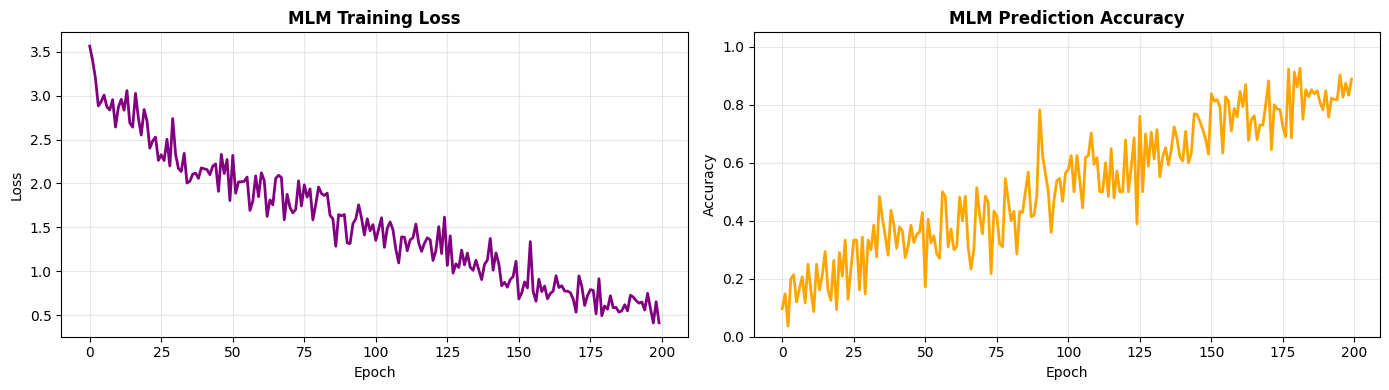

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(mlm_losses, linewidth=2, color='purple')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('MLM Training Loss', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(mlm_accuracies, linewidth=2, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('MLM Prediction Accuracy', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Test masked token prediction.

In [83]:
def predict_masked_token(text, mask_position, model, tokenizer, device):
    """Predict a masked token at a specific position."""
    model.eval()
    with torch.no_grad():
        # Encode text
        encoded = tokenizer.encode(text, max_length=40)
        
        # Store original token for comparison
        original_token_id = encoded[mask_position]
        original_token = tokenizer.idx2char[original_token_id]
        
        # Mask the token
        encoded[mask_position] = tokenizer.mask_token_id
        
        # Convert to tensor
        input_ids = torch.tensor([encoded]).to(device)
        
        # Predict
        logits = model(input_ids)  # (1, seq_len, vocab_size)
        
        # Get predictions for masked position
        masked_logits = logits[0, mask_position]  # (vocab_size,)
        probs = F.softmax(masked_logits, dim=-1)
        
        # Get top-5 predictions
        top_k = 5
        top_probs, top_indices = torch.topk(probs, top_k)
        
        predictions = []
        for prob, idx in zip(top_probs.cpu().numpy(), top_indices.cpu().numpy()):
            token = tokenizer.idx2char[idx]
            predictions.append((token, prob))
        
        return original_token, predictions

# Test predictions
test_text = "the cat sat on the mat"
mask_positions = [5, 9, 13]  # Positions of 'c', 's', 'o' (after [CLS])

print("Masked Token Predictions:")
print("=" * 70)
for pos in mask_positions:
    original, predictions = predict_masked_token(test_text, pos, mlm_model, mlm_tokenizer, device)
    print(f"\nPosition {pos} - Original token: '{original}'")
    print("Top 5 predictions:")
    for i, (token, prob) in enumerate(predictions, 1):
        marker = " <- CORRECT" if token == original else ""
        print(f"  {i}. '{token}' (prob: {prob:.2%}){marker}")

Masked Token Predictions:

Position 5 - Original token: 'c'
Top 5 predictions:
  1. 'c' (prob: 83.06%) <- CORRECT
  2. 'v' (prob: 6.60%)
  3. 'a' (prob: 2.30%)
  4. '[CLS]' (prob: 1.24%)
  5. 'z' (prob: 0.94%)

Position 9 - Original token: 's'
Top 5 predictions:
  1. 's' (prob: 67.23%) <- CORRECT
  2. 'm' (prob: 18.77%)
  3. 'n' (prob: 2.07%)
  4. 'o' (prob: 1.88%)
  5. 'r' (prob: 1.49%)

Position 13 - Original token: 'o'
Top 5 predictions:
  1. 'o' (prob: 74.54%) <- CORRECT
  2. ' ' (prob: 9.81%)
  3. 'm' (prob: 7.23%)
  4. 'u' (prob: 2.12%)
  5. 's' (prob: 1.63%)


**Key Insight**: MLM pre-training teaches BERT to understand context deeply. By predicting masked tokens using both left and right context, BERT learns rich bidirectional representations that transfer well to downstream tasks.

## 9. Comparing Bidirectional vs Unidirectional

Let's directly compare how bidirectional (BERT-style) and unidirectional (GPT-style) models process the same sentence.

Create a unidirectional model for comparison.

In [84]:
class UnidirectionalEncoderLayer(nn.Module):
    """Encoder layer with causal (unidirectional) attention."""
    
    def __init__(self, hidden_size, num_heads, intermediate_size, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        
        # Q, K, V projections
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, hidden_size)
        
        self.feed_forward = FeedForward(hidden_size, intermediate_size, dropout)
        self.ln1 = nn.LayerNorm(hidden_size)
        self.ln2 = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Apply causal masking so each token only attends to previous tokens.
        """
        batch_size, seq_len, hidden_size = x.shape
        
        # Manual attention with causal masking
        Q = self.query(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        
        # Apply causal mask
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0) == 0, -1e9)
        
        # Softmax and apply to values
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, hidden_size)
        attn_output = self.out(context)
        
        # Residual + LayerNorm
        x = self.ln1(x + self.dropout(attn_output))
        
        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.ln2(x + self.dropout(ff_output))
        
        return x, attn_weights

print("Unidirectional encoder layer created (GPT-style)")

Unidirectional encoder layer created (GPT-style)


Compare attention patterns side-by-side.

In [85]:
# Create both types of encoder layers
bidirectional_layer = BERTEncoderLayer(hidden_size=128, num_heads=4, intermediate_size=512)
unidirectional_layer = UnidirectionalEncoderLayer(hidden_size=128, num_heads=4, intermediate_size=512)

# Create sample input
sample_text = "bert model"
sample_encoded = mlm_tokenizer.encode(sample_text, max_length=15)
sample_input = torch.tensor([sample_encoded])

# Get embeddings
sample_embed = bert_mlm_base.embeddings(sample_input)

# Forward pass through both models
bidirectional_layer.eval()
unidirectional_layer.eval()

with torch.no_grad():
    bi_output = bidirectional_layer(sample_embed)
    uni_output, uni_attn = unidirectional_layer(sample_embed)

print("Forward pass completed for both models")
print(f"Input shape: {sample_embed.shape}")
print(f"Bidirectional output shape: {bi_output.shape}")
print(f"Unidirectional output shape: {uni_output.shape}")

# Visualize attention patterns
# Note: bidirectional_layer doesn't return attention weights by default
# So we'll create a custom visualization

Forward pass completed for both models
Input shape: torch.Size([1, 15, 128])
Bidirectional output shape: torch.Size([1, 15, 128])
Unidirectional output shape: torch.Size([1, 15, 128])


Visualize the key difference in attention patterns.

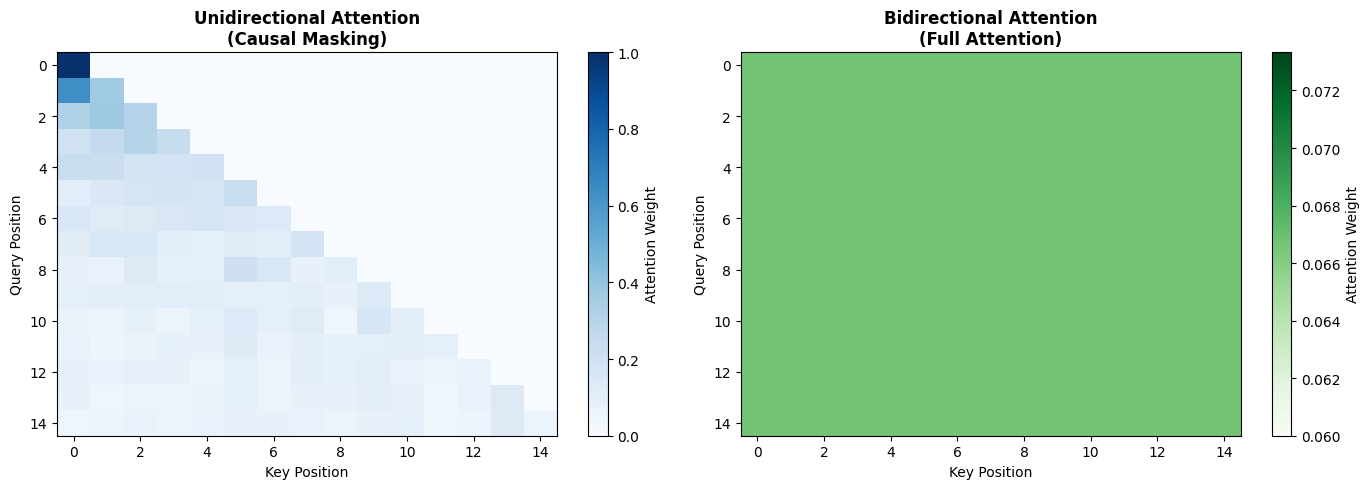


Key Difference:
- Unidirectional (left): Each position can only attend to itself and previous positions
  Notice the triangular pattern (lower-left filled, upper-right zero)
- Bidirectional (right): Each position can attend to ALL positions
  Notice the full matrix is active (no masking)


In [86]:
# Get attention from unidirectional model - need to average over batch dimension
uni_attn_sample = uni_attn[0, 0].detach().numpy()  # First sample, first head

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unidirectional attention (actual)
im1 = axes[0].imshow(uni_attn_sample, cmap='Blues', aspect='auto')
axes[0].set_title('Unidirectional Attention\n(Causal Masking)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Key Position')
axes[0].set_ylabel('Query Position')
plt.colorbar(im1, ax=axes[0], label='Attention Weight')

# Bidirectional attention (simulated full attention)
seq_len = uni_attn_sample.shape[0]
full_attn = np.ones((seq_len, seq_len)) / seq_len  # Uniform for illustration
im2 = axes[1].imshow(full_attn, cmap='Greens', aspect='auto')
axes[1].set_title('Bidirectional Attention\n(Full Attention)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Key Position')
axes[1].set_ylabel('Query Position')
plt.colorbar(im2, ax=axes[1], label='Attention Weight')

plt.tight_layout()
plt.show()

print("\nKey Difference:")
print("- Unidirectional (left): Each position can only attend to itself and previous positions")
print("  Notice the triangular pattern (lower-left filled, upper-right zero)")
print("- Bidirectional (right): Each position can attend to ALL positions")
print("  Notice the full matrix is active (no masking)")

## 10. Key Takeaways

### What We Learned:

1. **Bidirectional Context**: BERT uses full bidirectional attention, allowing each token to see both left and right context. This is fundamentally different from unidirectional models like GPT.

2. **Masked Language Modeling (MLM)**: BERT's pre-training objective masks random tokens and predicts them using full context. This forces the model to learn deep bidirectional representations.

3. **Special Tokens**: BERT uses [CLS], [SEP], [MASK], and [PAD] tokens for different purposes:
   - [CLS]: Sentence-level representation for classification
   - [SEP]: Separates sentence pairs
   - [MASK]: Used during pre-training
   - [PAD]: Handles variable-length sequences

4. **Architecture Components**:
   - Token + Position + Segment embeddings (all learned)
   - Multi-head self-attention (without causal masking)
   - Feed-forward networks with GELU activation
   - Layer normalization and residual connections

5. **Best For**: BERT excels at understanding tasks (classification, NER, QA) where full context is available. It's not suitable for autoregressive generation without modifications.

### Why BERT Matters:

- **Transfer Learning**: Pre-train once on large corpus, fine-tune for many tasks
- **State-of-the-art**: Achieved breakthrough results on 11 NLP tasks when released
- **Foundation**: Inspired many variants (RoBERTa, ALBERT, DistilBERT, etc.)

### Unidirectional vs Bidirectional Trade-offs:

**Unidirectional (GPT-style)**:
- Good for: Generation, next-token prediction
- Context: Only left (previous tokens)
- Use case: Text generation, completion

**Bidirectional (BERT-style)**:
- Good for: Understanding, classification, extraction
- Context: Both left and right (full sentence)
- Use case: Classification, NER, QA

Modern models like T5 and GPT-3 use different approaches to get benefits of both!

## 11. Further Exploration

To deepen your understanding of BERT:

1. **Try different masking probabilities**: How does changing the 15% mask rate affect learning?

2. **Experiment with Next Sentence Prediction (NSP)**: BERT's second pre-training task (not covered here)

3. **Compare with RoBERTa**: A BERT variant that removes NSP and uses dynamic masking

4. **Fine-tune on specific tasks**: Try Named Entity Recognition or Question Answering

5. **Analyze attention patterns**: Which heads learn syntactic vs semantic patterns?

6. **Study BERT variants**: DistilBERT (smaller), ALBERT (parameter-efficient), ELECTRA (different pre-training)

### Resources:
- Original paper: "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding" (Devlin et al., 2018)
- Hugging Face Transformers library for production-ready BERT models
- The Illustrated BERT (Jay Alammar) for visual explanations